# Predicting Financial Well-Being — Multivariate Linear Regression

**Mission.** Move young people toward financial freedom and economic independence.

**Problem (use case).** Given a few things a person can actually influence — their
financial *skill*, financial *knowledge*, income, savings, employment, age,
education and household size — predict their **Financial Well-Being score**
(`FWBscore`, a continuous 0–100 scale). The score tells someone where they stand,
and the model shows which levers move it most. This is a regression problem with a
continuous target, and it is deliberately **not** house-price prediction.

**Dataset.** CFPB *National Financial Well-Being Survey 2016* Public Use File —
a public U.S. government dataset (consumerfinance.gov / data.gov), 6,394 adults,
217 columns. We use `FWBscore` as the target and a small, interpretable subset of
features. Source: https://www.consumerfinance.gov/data-research/financial-well-being-survey-data/


## 1. Setup and load the data

In [1]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# import the shared cleaning / preprocessing / model logic that the API also uses
sys.path.append(os.path.abspath(os.path.join("..", "API")))
import ml

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

raw = pd.read_csv("data/financial_wellbeing.csv")
print("Raw shape:", raw.shape)
raw[["FWBscore", "FSscore", "KHscore", "PPINCIMP", "SAVINGSRANGES",
     "agecat", "PPEDUC", "EMPLOY", "PPHHSIZE"]].head()

Raw shape: (6394, 217)


,FWBscore,FSscore,KHscore,PPINCIMP,SAVINGSRANGES,agecat,PPEDUC,EMPLOY,PPHHSIZE
0,55,44,1.267,7,6,8,4,8,1
1,51,43,-0.570,6,2,3,2,2,2
2,49,42,-0.188,6,4,3,3,2,3
3,49,42,-1.485,8,-1,3,2,99,1
4,49,42,-1.900,7,98,2,2,2,5


## 2. Choose the columns (feature selection rationale)

The raw file has 217 columns, most of them individual survey items that make up
the scored scales. Feeding all 217 in would leak the target and be impossible to
serve from an app. We keep **8 interpretable predictors** plus the target:

| Feature | Meaning | Type | Why kept |
|---|---|---|---|
| `FSscore` | Financial **skill** scale | numeric | strongest actionable driver of well-being |
| `KHscore` | Financial **knowledge** score | numeric | knowledge is improvable through education |
| `PPINCIMP` | Household **income** band (1–9) | ordinal | economic capacity |
| `SAVINGSRANGES` | **Savings** band (1–7) | ordinal | buffer against shocks |
| `agecat` | **Age** band (1–8) | ordinal | well-being rises with life stage |
| `PPEDUC` | **Education** (1–5) | ordinal | human capital |
| `EMPLOY` | **Employment** status (1–8) | nominal | no natural order → one-hot |
| `PPHHSIZE` | **Household size** (1–5) | numeric | dependants stretch a budget |

**Columns dropped:** the ~200 raw scale items (`FWB1_*`, `FS1_*`, `FINKNOWL*`, …)
because they *define* the scores and would leak the target; plus survey admin
columns (`PUF_ID`, `sample`, weights) that carry no signal about a person.


## 3. Clean the survey codes

Survey files use sentinel codes for non-answers: `-1` (valid skip), `98`
(“don’t know”), `99` (“refused”), and `-4` on the score columns. These are not real
numbers and would poison a regression, so we drop rows that carry them on any
feature we use. `KHscore` is a standardised knowledge score that is *legitimately*
negative, so it is left alone. The cleaning lives in `ml.clean()` so the API cleans
uploaded data the exact same way.

In [2]:
df = ml.clean(raw)[ml.FEATURES + [ml.TARGET]].copy()
print(f"Rows before cleaning: {len(raw):>5}")
print(f"Rows after cleaning:  {len(df):>5}  ({len(raw) - len(df)} sentinel/missing rows dropped)")
print("\nFeatures used:", ml.FEATURES)
print("Target:", ml.TARGET)
df.describe().round(2)

Rows before cleaning:  6394
Rows after cleaning:   5144  (1250 sentinel/missing rows dropped)

Features used: ['FSscore', 'KHscore', 'PPHHSIZE', 'PPINCIMP', 'SAVINGSRANGES', 'agecat', 'PPEDUC', 'EMPLOY']
Target: FWBscore


,FSscore,KHscore,PPHHSIZE,PPINCIMP,SAVINGSRANGES,agecat,PPEDUC,EMPLOY,FWBscore
count,5144.00,5144.00,5144.00,5144.00,5144.00,5144.00,5144.00,5144.00,5144.00
mean,50.70,0.01,2.53,5.65,4.49,4.39,3.22,4.25,55.82
std,12.61,0.80,1.22,2.64,1.80,2.11,1.17,2.70,14.45
min,5.00,-2.05,1.00,1.00,1.00,1.00,1.00,1.00,14.00
25%,42.00,-0.57,2.00,3.00,3.00,3.00,2.00,2.00,47.00
50%,50.00,0.24,2.00,6.00,5.00,4.00,3.00,3.00,56.00
75%,57.00,0.71,3.00,8.00,6.00,6.00,4.00,8.00,65.00
max,85.00,1.27,5.00,9.00,7.00,8.00,5.00,8.00,95.00


## 4. Visualisations and interpretation

### 4.1 Distribution of the target

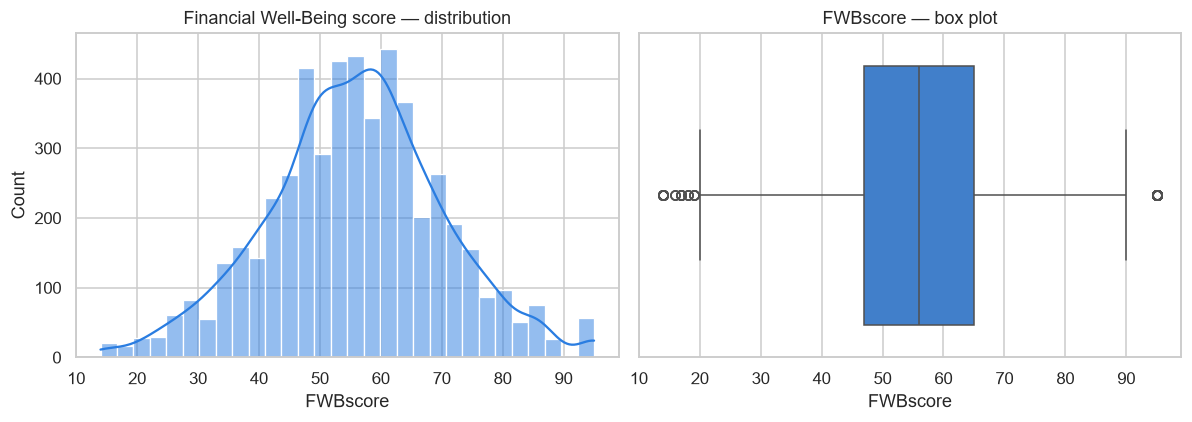

mean=55.8  median=56.0  std=14.5  min=14  max=95


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["FWBscore"], bins=30, kde=True, color="#2A7DE1", ax=ax[0])
ax[0].set_title("Financial Well-Being score — distribution")
ax[0].set_xlabel("FWBscore")
sns.boxplot(x=df["FWBscore"], color="#2A7DE1", ax=ax[1])
ax[1].set_title("FWBscore — box plot")
plt.tight_layout(); plt.show()
print("mean=%.1f  median=%.1f  std=%.1f  min=%d  max=%d" % (
    df.FWBscore.mean(), df.FWBscore.median(), df.FWBscore.std(),
    df.FWBscore.min(), df.FWBscore.max()))

**Interpretation.** The score is roughly bell-shaped and centred in the mid-50s
with no extreme skew or fat tail. That is good news for a linear model: there is no
heavy right tail (unlike incomes or house prices) dragging the fitted line, so the
mean-squared-error objective is not dominated by a handful of outliers.

### 4.2 Well-being vs financial skill and income

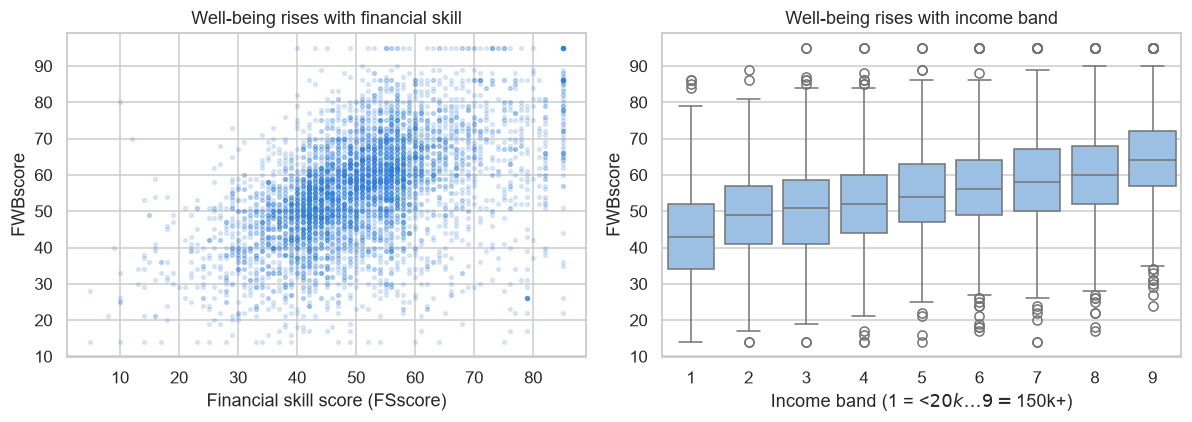

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(df["FSscore"], df["FWBscore"], s=6, alpha=0.15, color="#2A7DE1")
ax[0].set_xlabel("Financial skill score (FSscore)")
ax[0].set_ylabel("FWBscore")
ax[0].set_title("Well-being rises with financial skill")
sns.boxplot(x="PPINCIMP", y="FWBscore", data=df, ax=ax[1], color="#8Fc1ef")
ax[1].set_xlabel("Income band (1 = <$20k … 9 = $150k+)")
ax[1].set_title("Well-being rises with income band")
plt.tight_layout(); plt.show()

**Interpretation.** `FSscore` has a clear, roughly linear positive relationship
with the target — it is the lead feature. Income also trends upward but flattens at
the top bands: extra income helps most for lower earners. Both relationships are
monotonic, which is exactly what linear and tree models can exploit.

### 4.3 Correlation heatmap

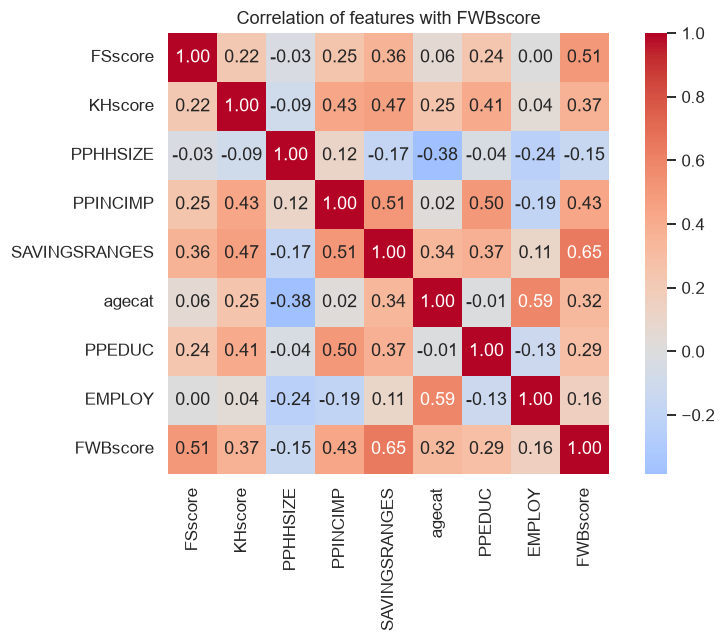

FWBscore         1.000
SAVINGSRANGES    0.648
FSscore          0.506
PPINCIMP         0.429
KHscore          0.369
agecat           0.322
PPEDUC           0.291
EMPLOY           0.161
PPHHSIZE        -0.150
Name: FWBscore, dtype: float64


In [5]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation of features with FWBscore")
plt.tight_layout(); plt.show()
print(corr["FWBscore"].sort_values(ascending=False).round(3))

**Interpretation.** Ranked by correlation with the target, `FSscore` leads by a
wide margin, followed by savings, income and knowledge. Household size is weakly
*negative* (more dependants, lower well-being). No two predictors are strongly
correlated with each other, so there is little multicollinearity to worry about and
every feature earns its place.

### 4.4 Well-being by employment status

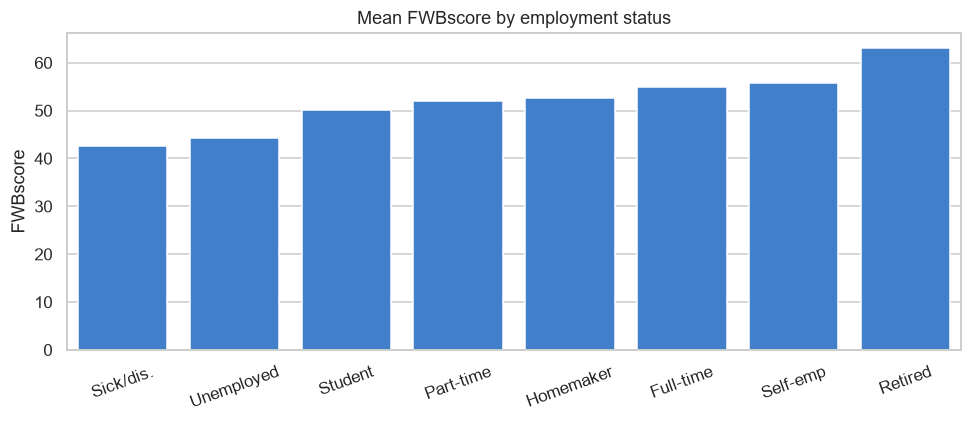

In [6]:
emp_labels = {1:"Self-emp",2:"Full-time",3:"Part-time",4:"Homemaker",
              5:"Student",6:"Sick/dis.",7:"Unemployed",8:"Retired"}
order = df.groupby("EMPLOY")["FWBscore"].mean().sort_values().index
plt.figure(figsize=(9, 4))
sns.barplot(x="EMPLOY", y="FWBscore", data=df, order=order,
            color="#2A7DE1", errorbar=None)
plt.xticks(range(len(order)), [emp_labels[i] for i in order], rotation=20)
plt.title("Mean FWBscore by employment status"); plt.xlabel("")
plt.tight_layout(); plt.show()

**Interpretation.** Employment groups differ by ~15 points, and the order is not
monotonic (retirees and the self-employed score high; the unemployed and
sick/disabled score low). Because there is no natural ranking, `EMPLOY` is treated
as a **nominal** feature and one-hot encoded rather than ordinal encoded.

## 5. Feature engineering & standardisation

Three groups, each encoded the right way (all wrapped in `ml.build_preprocessor()`):

- **Numeric** (`FSscore`, `KHscore`, `PPHHSIZE`) → `StandardScaler` (mean 0, std 1).
  Standardising matters for gradient descent: without it the large-range `FSscore`
  would dominate the gradient and the learning rate could not suit every weight.
- **Ordinal** (`PPINCIMP`, `SAVINGSRANGES`, `agecat`, `PPEDUC`) → `OrdinalEncoder`
  with the natural low→high order, then scaled. This keeps “higher band = higher
  value”, which is real information a one-hot encoding would throw away.
- **Nominal** (`EMPLOY`) → `OneHotEncoder`, because its categories have no order.

The whole thing is a `ColumnTransformer` inside each model `Pipeline`, so the exact
same transformation is applied at train time, at test time and in the live API.

In [7]:
from sklearn.model_selection import train_test_split

X, y = df[ml.FEATURES], df[ml.TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

pre = ml.build_preprocessor()
Xtr = pre.fit_transform(X_train, y_train)
Xte = pre.transform(X_test)
print("Design matrix after preprocessing:", Xtr.shape, "(one-hot expands EMPLOY)")
print("Column means after standardising (should be ~0):",
      np.round(Xtr[:, :3].mean(axis=0), 3))

Train: (4115, 8)  Test: (1029, 8)
Design matrix after preprocessing: (4115, 15) (one-hot expands EMPLOY)
Column means after standardising (should be ~0): [ 0.  0. -0.]


## 6. Optimise a linear model with gradient descent — loss curve

Here is the core Task-1 model: a linear regressor trained with **stochastic
gradient descent** (`SGDRegressor`), optimised epoch by epoch. After each pass we
record the **training** and **test** loss (RMSE) so we can watch it converge and
check for overfitting. The target is standardised for the descent and the RMSE is
reported back in the original score units.

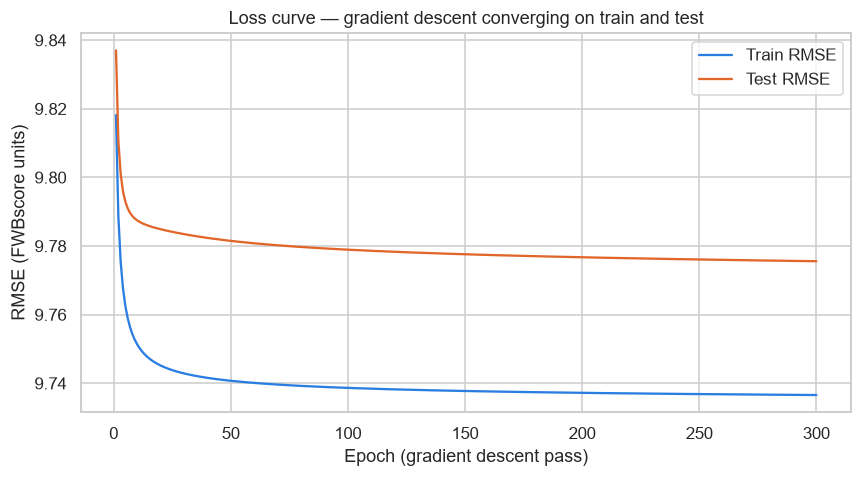

Final train RMSE=9.74  test RMSE=9.78


In [8]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

# standardise the target for stable gradient descent, invert for reporting
y_mean, y_std = y_train.mean(), y_train.std()
ytr_s = (y_train.values - y_mean) / y_std
yte_s = (y_test.values - y_mean) / y_std

sgd = SGDRegressor(loss="squared_error", penalty="l2", alpha=1e-3,
                   learning_rate="invscaling", eta0=0.01, random_state=RANDOM_STATE,
                   warm_start=True, max_iter=1, tol=None)

n_epochs = 300
train_rmse, test_rmse = [], []
for _ in range(n_epochs):
    sgd.partial_fit(Xtr, ytr_s)
    tr = np.sqrt(mean_squared_error(y_train, sgd.predict(Xtr) * y_std + y_mean))
    te = np.sqrt(mean_squared_error(y_test,  sgd.predict(Xte) * y_std + y_mean))
    train_rmse.append(tr); test_rmse.append(te)

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, n_epochs + 1), train_rmse, label="Train RMSE", color="#2A7DE1")
plt.plot(range(1, n_epochs + 1), test_rmse, label="Test RMSE", color="#E1662A")
plt.xlabel("Epoch (gradient descent pass)"); plt.ylabel("RMSE (FWBscore units)")
plt.title("Loss curve — gradient descent converging on train and test")
plt.legend(); plt.tight_layout(); plt.show()
print("Final train RMSE=%.2f  test RMSE=%.2f" % (train_rmse[-1], test_rmse[-1]))

**Interpretation.** Both curves fall steeply then flatten to nearly the same value.
The tiny gap between train and test means the model is **not overfitting** — it
generalises. The floor the curves settle at is the irreducible error: with only
these 8 features we cannot explain the part of well-being driven by things we did
not measure (health shocks, personality, local cost of living).

## 7. Compare four regression algorithms

We now compare the stochastic linear model against three other implementations:
a from-scratch **batch gradient descent** linear model, a **Random Forest**, and a
**Decision Tree**. All four share the same preprocessing and the same train/test
split; the loss metric is **test RMSE** (lower is better).

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

models = ml.candidate_models()   # the 4 pipelines, defined once in ml.py
results = {}
fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    tr_pred = pipe.predict(X_train)
    results[name] = {
        "Train RMSE": np.sqrt(mean_squared_error(y_train, tr_pred)),
        "Test RMSE":  np.sqrt(mean_squared_error(y_test, pred)),
        "Test MAE":   mean_absolute_error(y_test, pred),
        "Test R2":    r2_score(y_test, pred),
    }
    fitted[name] = pipe

table = pd.DataFrame(results).T.round(3).sort_values("Test RMSE")
table

,Train RMSE,Test RMSE,Test MAE,Test R2
Random Forest,6.787,9.711,7.438,0.536
SGD Linear Regression,9.743,9.763,7.427,0.531
Batch GD Linear Regression,9.734,9.763,7.417,0.531
Decision Tree,8.956,10.197,7.817,0.488


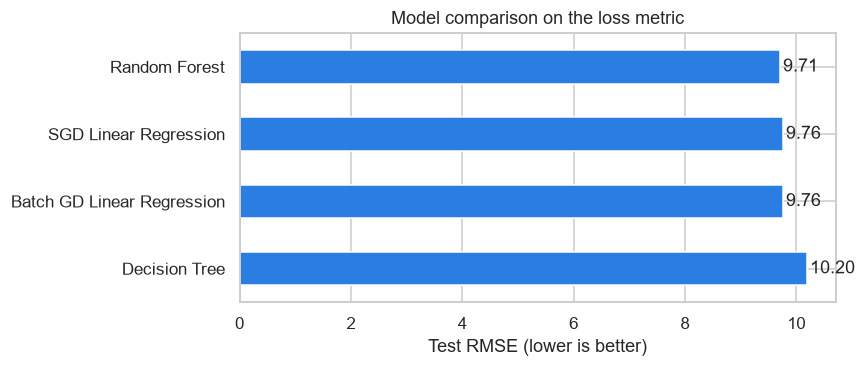

In [10]:
ax = table["Test RMSE"].plot(kind="barh", figsize=(8, 3.5), color="#2A7DE1")
ax.invert_yaxis()
ax.set_xlabel("Test RMSE (lower is better)")
ax.set_title("Model comparison on the loss metric")
for i, v in enumerate(table["Test RMSE"]):
    ax.text(v + 0.05, i, f"{v:.2f}", va="center")
plt.tight_layout(); plt.show()

**Interpretation.** The scores are close, which is itself a finding: on this
tabular data with mostly monotonic relationships, a well-standardised **linear
model matches the trees**. The linear models also show the smallest train↔test gap,
while the single Decision Tree overfits most (best train, worst test). We therefore
prefer a linear model: comparable accuracy, better generalisation, far more
interpretable, and cheap to serve.

## 8. Scatter plots — before and after fitting the line

Left: the raw data (financial skill vs well-being), *before* any model — just a
cloud of points. Right: the *same* data with the fitted regression line drawn
through it, showing where a simple one-feature linear fit passes.

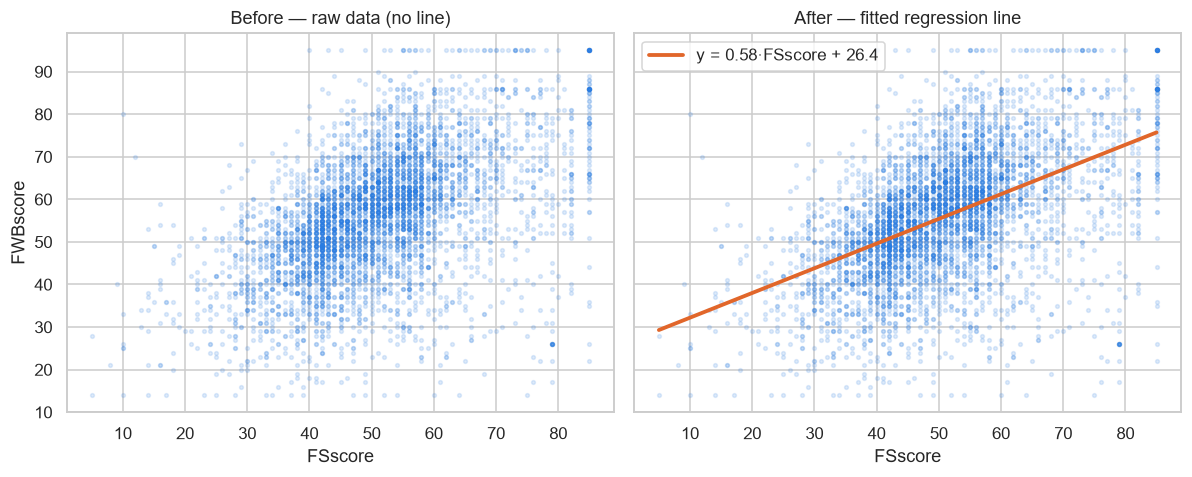

In [11]:
from sklearn.linear_model import LinearRegression

xline = df["FSscore"].values.reshape(-1, 1)
yline = df["FWBscore"].values
lin1 = LinearRegression().fit(xline, yline)
xs = np.linspace(xline.min(), xline.max(), 100).reshape(-1, 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
ax[0].scatter(xline, yline, s=6, alpha=0.15, color="#2A7DE1")
ax[0].set_title("Before — raw data (no line)")
ax[0].set_xlabel("FSscore"); ax[0].set_ylabel("FWBscore")

ax[1].scatter(xline, yline, s=6, alpha=0.15, color="#2A7DE1")
ax[1].plot(xs, lin1.predict(xs), color="#E1662A", lw=2.5,
           label=f"y = {lin1.coef_[0]:.2f}·FSscore + {lin1.intercept_:.1f}")
ax[1].set_title("After — fitted regression line"); ax[1].set_xlabel("FSscore")
ax[1].legend()
plt.tight_layout(); plt.show()

The full multivariate model cannot be drawn on one axis, so we also check it with a
**predicted-vs-actual** scatter. Points hugging the dashed 45° line are good
predictions.

Lowest test RMSE: Random Forest. Chosen (parsimony rule): SGD Linear Regression


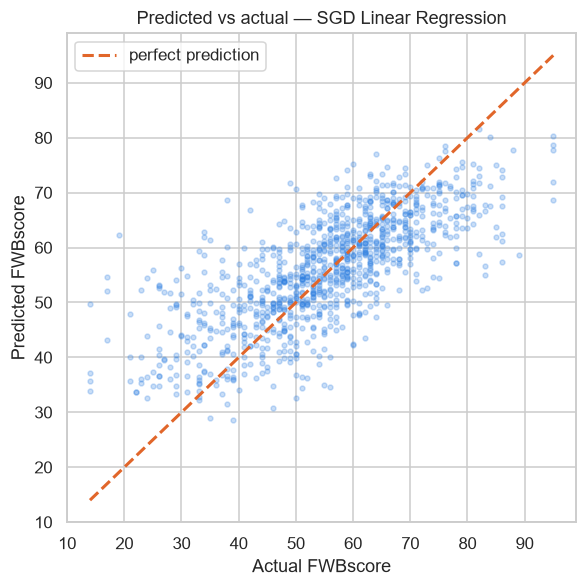

Best model: SGD Linear Regression


In [12]:
# Selection rule (also used by the API's /retrain): pick the lowest test RMSE,
# but PREFER a linear model when it is within 1% of the best. The linear models
# tie the trees on test error while generalising better (smaller train-test gap)
# and are tiny and interpretable to serve, so parsimony breaks the near-tie.
raw_best = min(results, key=lambda k: results[k]["Test RMSE"])
linear = ["SGD Linear Regression", "Batch GD Linear Regression"]
best_linear = min(linear, key=lambda k: results[k]["Test RMSE"])
if results[best_linear]["Test RMSE"] <= results[raw_best]["Test RMSE"] * 1.01:
    best_name = best_linear
else:
    best_name = raw_best
best_model = fitted[best_name]
pred_best = best_model.predict(X_test)
print(f"Lowest test RMSE: {raw_best}. Chosen (parsimony rule): {best_name}")

plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test, pred_best, s=10, alpha=0.25, color="#2A7DE1")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "--", color="#E1662A", lw=2, label="perfect prediction")
plt.xlabel("Actual FWBscore"); plt.ylabel("Predicted FWBscore")
plt.title(f"Predicted vs actual — {best_name}")
plt.legend(); plt.tight_layout(); plt.show()
print("Best model:", best_name)

## 9. Save the best model and metadata

The best pipeline (lowest test RMSE) is saved with `joblib`. Because the whole
preprocessing lives *inside* the pipeline, the API only needs to hand it the raw
feature values. We also save metadata (metrics + valid input ranges) and the
cleaned training data, which the `/retrain` endpoint reuses.

In [13]:
MODEL_DIR = os.path.join("..", "API", "model")
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(best_model, os.path.join(MODEL_DIR, "best_model.pkl"))
df.to_csv(os.path.join(MODEL_DIR, "training_data.csv"), index=False)

value_labels = {
    "PPINCIMP": {1:"<$20k",2:"$20-29.9k",3:"$30-39.9k",4:"$40-49.9k",5:"$50-59.9k",
                 6:"$60-74.9k",7:"$75-99.9k",8:"$100-149.9k",9:"$150k+"},
    "SAVINGSRANGES": {1:"$0",2:"$1-99",3:"$100-999",4:"$1,000-4,999",
                      5:"$5,000-19,999",6:"$20,000-74,999",7:"$75,000+"},
    "agecat": {1:"18-24",2:"25-34",3:"35-44",4:"45-54",5:"55-61",6:"62-69",
               7:"70-74",8:"75+"},
    "PPEDUC": {1:"< High school",2:"High school",3:"Some college/Associate",
               4:"Bachelor's",5:"Graduate/Professional"},
    "EMPLOY": {1:"Self-employed",2:"Full-time employee",3:"Part-time employee",
               4:"Homemaker",5:"Full-time student",6:"Sick/disabled",
               7:"Unemployed",8:"Retired"},
    "PPHHSIZE": {1:"1",2:"2",3:"3",4:"4",5:"5+"},
}
metadata = {
    "best_model": best_name,
    "target": ml.TARGET,
    "target_range": [float(df.FWBscore.min()), float(df.FWBscore.max())],
    "features": ml.FEATURES,
    "numeric_ranges": {
        "FSscore": [float(df.FSscore.min()), float(df.FSscore.max())],
        "KHscore": [float(df.KHscore.min()), float(df.KHscore.max())],
        "PPHHSIZE": [1, 5],
    },
    "valid_values": ml.VALID_VALUES,
    "value_labels": value_labels,
    "metrics": {k: {mk: round(float(mv), 3) for mk, mv in v.items()}
                for k, v in results.items()},
}
with open(os.path.join(MODEL_DIR, "model_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:", best_name)
print(" -> best_model.pkl, model_metadata.json, training_data.csv in API/model/")

Saved: SGD Linear Regression
 -> best_model.pkl, model_metadata.json, training_data.csv in API/model/


## 10. Prediction script (feeds Task 2)

A single function that loads the saved model and turns a raw profile into a
predicted score. This is exactly the logic the FastAPI `/predict` endpoint reuses
in Task 2. A copy is also saved as a standalone script, `make_prediction.py`.

In [14]:
def predict_wellbeing(profile: dict) -> float:
    """profile: raw feature values keyed by ml.FEATURES. Returns FWBscore (0-100)."""
    model = joblib.load(os.path.join(MODEL_DIR, "best_model.pkl"))
    row = pd.DataFrame([profile])[ml.FEATURES]
    return float(model.predict(row)[0])

example = {"FSscore": 55, "KHscore": 0.4, "PPHHSIZE": 3, "PPINCIMP": 7,
           "SAVINGSRANGES": 5, "agecat": 2, "PPEDUC": 4, "EMPLOY": 2}
print("Example profile:", example)
print("Predicted FWBscore: %.1f / 100" % predict_wellbeing(example))

Example profile: {'FSscore': 55, 'KHscore': 0.4, 'PPHHSIZE': 3, 'PPINCIMP': 7, 'SAVINGSRANGES': 5, 'agecat': 2, 'PPEDUC': 4, 'EMPLOY': 2}
Predicted FWBscore: 57.7 / 100
